In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load data
data=pd.read_csv("./dataset/smartcart_customers.csv")


In [ ]:
data.shape  # (2240, 22) 
data.isnull().sum() # Income 24 -> take the median income and fill then with median values


## Data Preprocessing Learning

#### 1 Handle Missing Values

In [ ]:
data['Income']= data['Income'].fillna(data['Income'].median())

#### 2 Feature Engineering 

In [ ]:
# 1- Year of Birth into Age
data['Age']=2026-data['Year_Birth']

In [ ]:
# 2- Customer joining Days 
data['Dt_Customer']= pd.to_datetime(data['Dt_Customer'],dayfirst=True)
refrence_date=data['Dt_Customer'].max()

# Create A New Feature Customer tenure  Days 
data['Customer_Tenure']= (refrence_date - data['Dt_Customer']).dt.days ## total number of days 


In [ ]:
data.columns

In [ ]:
#3  Total - Spending 
data['Total_Spending']=data['MntWines']+data['MntFruits']+ data['MntMeatProducts']+data['MntFishProducts']+data['MntSweetProducts']+data['MntGoldProds']

In [ ]:
# 4  Children
data['Total_Children']=data["Kidhome"]+data['Teenhome']

In [ ]:
# 5  Education
data['Education'].value_counts()

# Convert into Three Basic Catgories

# Undergraduate  , Graduate, PostGraduate
data['Education']=data['Education'].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduate":"Graduation",
    "Master":"PostGraduate",
    "PhD":"PostGraduate"   
})

# data['Education'].value_counts()

In [ ]:
# 6  Marital Status 
data['Marital_Status'].value_counts()

data['Living_With']=data['Marital_Status'].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Alone":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})

data['Living_With'].value_counts()


#### Drop UNnecessary Columns

In [ ]:
# I Remove Columns
# data= data.drop("ID",axis=1)   data.columns

cols=['Year_Birth','Marital_Status','Kidhome','Teenhome','Dt_Customer']
spending_cols=['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

drop_cols=cols+spending_cols

data_cleaned= data.drop(columns=drop_cols)

In [ ]:
data_cleaned.to_csv('customer_data_updated.csv', index=False)

In [ ]:
data_cleaned.columns

## Handling With Outliers 

In [ ]:
numeric_columns=["Income","Recency","Response","Age","Total_Spending","Total_Children"]

#  Relative plots of some features - Pair Plots
sns.pairplot(data_cleaned[numeric_columns]) 

plt.savefig('01-pair_plots.png', dpi=300, bbox_inches='tight')


In [ ]:
# Remove the Outliers 
print("Data Size With outliers",len(data_cleaned))

data_cleaned= data_cleaned[data_cleaned['Age']<90] # remove the age outliers
data_cleaned= data_cleaned[data_cleaned['Income']<600_000] # remove the Income Outliers

print("Data Size WithOut outliers",len(data_cleaned))

## Heatmap

In [ ]:
corr= data_cleaned.corr(numeric_only=True)

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
    
)

plt.savefig('02-heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

# income vs total_spending corr -> 0.79
# income vs catelog purchase -> 0.69
# income vs store purchsed -> 0.63
#  # of wesbite viste s -.65
# spending catelog purchses 0.78
# store purchases 0.68

## Feature Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
data.head()

In [ ]:
ohe=OneHotEncoder()
# drop first in clustering we does not need 
cat_cols=["Education","Living_With"]

encoded_cols=ohe.fit_transform(data_cleaned[cat_cols])


In [ ]:
encoded_df=pd.DataFrame(
    encoded_cols.toarray(),
    columns=ohe.get_feature_names_out(cat_cols),
    index=data_cleaned.index
)

In [ ]:
encoded_data=pd.concat([data_cleaned.drop(columns=cat_cols), encoded_df],axis=1 )

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X=encoded_data
sc= StandardScaler()
X_scaled= sc.fit_transform(X)

## Visulize Data

In [83]:
# Apply PCA TO REDUCE DIMENSIONS 
# 2D
from sklearn.decomposition import PCA

In [84]:
pca=PCA(n_components=2)
X_pca= pca.fit_transform(X_scaled)

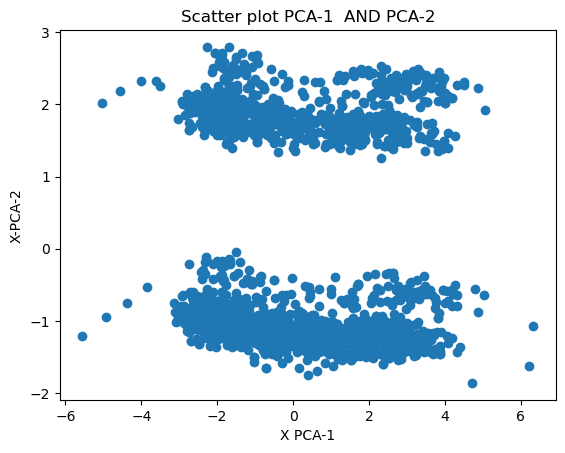

array([0.23163158, 0.11385454])

In [85]:
# Plot
plt.scatter(X_pca[:,0],X_pca[:,1])
plt.xlabel("X PCA-1")
plt.ylabel('X-PCA-2')
plt.title("Scatter plot PCA-1  AND PCA-2")
plt.savefig('03-scatter-pca.png', dpi=300, bbox_inches='tight')
plt.show()
pca.explained_variance_ratio_  # array([0.23163158, 0.11385454])


In [88]:
# 3D 
pca=PCA(n_components=3)
X_pca= pca.fit_transform(X_scaled)

In [89]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

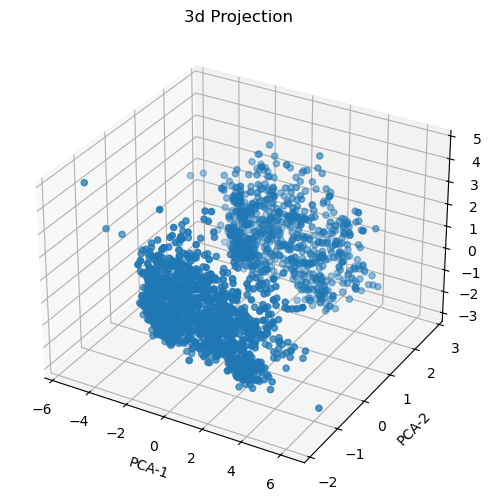

In [94]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot (111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")
ax.set_zlabel("PCA-3")
ax.set_title("3d Projection ")
plt.savefig('04-3d_projectio.png', dpi=300, bbox_inches='tight')
plt.show()